### Imports

In [22]:
"""Imports."""
import math
import numpy as np
import matplotlib.pyplot as plt
from color_utils import srgb_to_oklab, oklab_to_srgb, oklab_dist
from file_utils import get_image
from image_utils import l_flatten, print_image, print_oklab_l, get_color_positions
# from PIL import Image

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
# PIL Image has functions that handle resizing,
# rotation, and cropping, as well as a 256-palette getter.

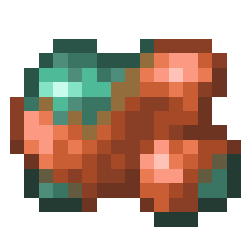

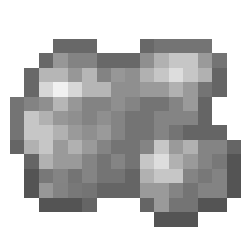

In [24]:
# Get image from file.

# img = get_image("asve", "apple.png")
# img = get_image("caverns_and_chasms", "music_disc_copy.png")
img = get_image("vanilla", "raw_copper.png")
# img = get_image("vanilla", "amethyst_shard.png")
# img = get_image("scratch", "snake_test.png")
# img = get_image("create", "blaze_cake.png")
# img = get_image("reimagined", "golden_apple.png")
# img = get_image("reimagined", "egg.png")
# img = get_image("asve", "raw_gold.png")
# img = get_image("vanilla", "recovery_compass_00.png")

%matplotlib inline
print_image(img)

# srgb array
img_arr = np.asarray(img)

# oklab array
oklab_arr = srgb_to_oklab(img_arr)

# L array
print_oklab_l(oklab_arr)
# lum_arr = l_flatten(oklab_arr)

In [25]:
# Get unordered color index

color_positions = get_color_positions(oklab_arr)
unique_colors = list(color_positions.keys())
unique_colors.append((0, 0, 0, 0))
color_idxs = {tuple(color): i for i, color in enumerate(unique_colors)}

# Initialize matrices
N = len(unique_colors)
adjacency_matrix = np.zeros((N, N), dtype=bool)
lum_diff_matrix = np.zeros((N, N), dtype=float)
distance_matrix = np.full((N, N), dtype=float, fill_value=np.inf)

neighbors = [
                   (0,1),
    (1,-1), (1,0), (1,1)
]
maxy, maxx, _ = oklab_arr.shape
for y in range(maxy):
    for x in range(maxx):
        color = oklab_arr[y, x]
        for dy, dx in neighbors:
            ny = y + dy
            nx = x + dx
            if ny<0 or nx<0 or ny >= maxy or nx >= maxx:
                continue

            # Colors
            c1 = color
            c2 = oklab_arr[ny, nx]

            colors_are_same = np.array_equal(c1, c2)
            if colors_are_same:
                continue

            transparent_involved = (len(c1) == 4 and c1[3] == 0) or (len(c2) == 4 and c2[3] == 0)
            if transparent_involved:
                # no diagonals allowed
                if not (dy == 0 or dx == 0):
                    continue
                # color -> transparent
                if len(c1) == 4 and c1[3] == 0:
                    c1, c2 = c2, c1
            else:
                # higher L -> lower L
                if c1[0] < c2[0]:
                    c1, c2 = c2, c1

            # c1 >= c2
            idx1 = color_idxs[tuple(c1)]
            idx2 = color_idxs[tuple(c2)]

            # no need to recompute
            if adjacency_matrix[idx1, idx2]:
                continue

            distance_matrix[idx1, idx2] = oklab_dist(c1, c2)
            lum_diff_matrix[idx1, idx2] = c1[0] - c2[0]

            # angle = math.acos(lum_diff_matrix[10, 7] / distance_matrix[10, 7])
            if (lum_diff_matrix[idx1, idx2] / distance_matrix[idx1, idx2]) < 0.25:
                continue

            adjacency_matrix[idx1, idx2] = True

# Distances of zero are not valid
distance_matrix[distance_matrix == 0] = np.inf

# Final decision
ramp_matrix = np.zeros((N, N), dtype=bool)

row_indices = np.arange(N-1)
col_indices = np.argmin(distance_matrix, axis=1)[:-1]

ramp_matrix[row_indices, col_indices] = True

print(adjacency_matrix)
print(lum_diff_matrix)
print(distance_matrix)
print(ramp_matrix)

[[False False False False False False False False False False False False
  False False False False  True]
 [ True False False False False False False False False False  True False
  False False False  True  True]
 [ True False False  True False False False False False False False False
  False  True  True  True False]
 [ True  True False False False False False False False False False False
  False False  True  True False]
 [ True  True False  True False False False False False False False False
  False  True False False False]
 [ True  True  True  True  True False False  True False False  True False
  False  True  True  True False]
 [False  True  True  True  True  True False  True False False  True False
  False  True False False False]
 [False  True False  True  True False False False False False  True False
  False  True  True  True False]
 [ True False  True  True  True False False False False False False False
  False False False False False]
 [False False False False False  True

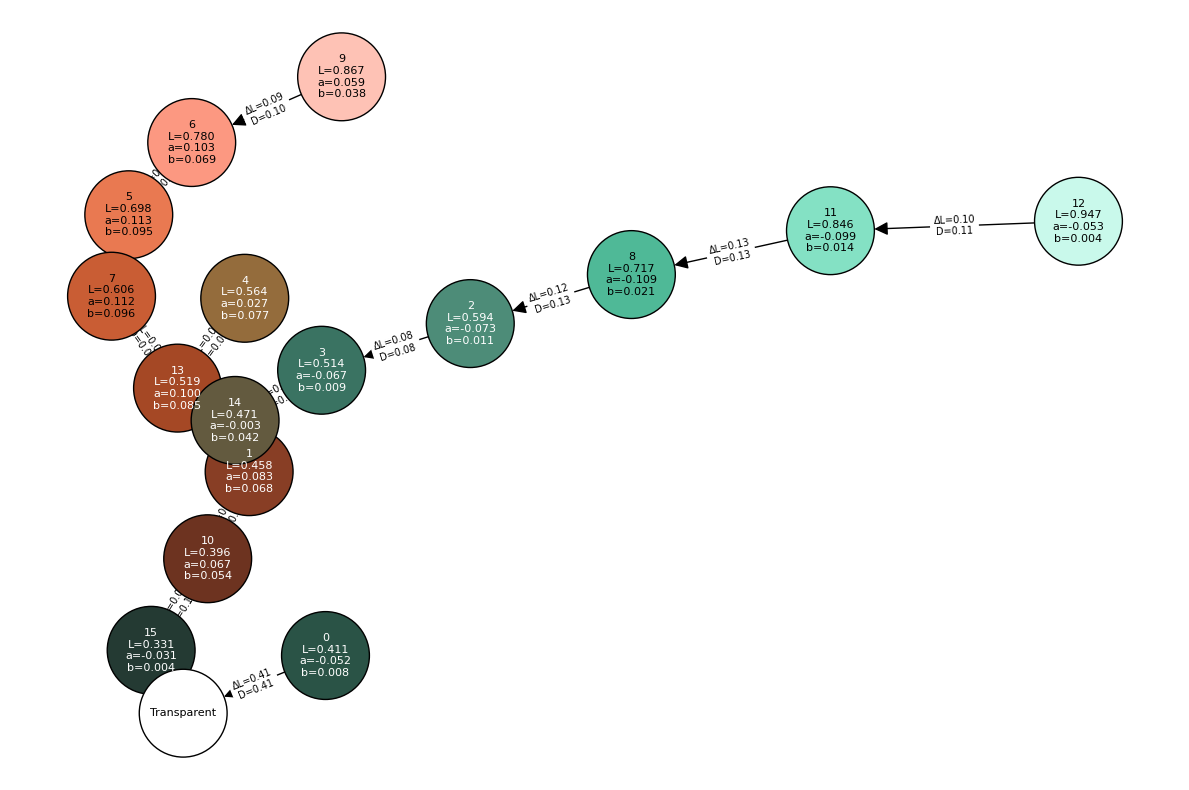

In [26]:
import networkx as nx

G = nx.DiGraph()

# ---- Nodes ----
for color, idx in color_idxs.items():

    # Handle transparent node
    if len(color) == 4 and color[3] == 0:
        rgb = (1, 1, 1)
        L = 1.0
        label = "Transparent"
    else:
        rgb = oklab_to_srgb(np.array(color)) / 255
        rgb = np.clip(rgb, 0, 1)
        L = color[0]

        label = (
            f"{idx}\n"
            f"L={color[0]:.3f}\n"
            f"a={color[1]:.3f}\n"
            f"b={color[2]:.3f}"
        )

    G.add_node(
        idx,
        color=rgb,
        label=label,
        L=L
    )

# ---- Edges ----
for i in range(N):
    for j in range(N):

        if not ramp_matrix[i, j]:
            continue

        G.add_edge(
            i,
            j,
            lum=lum_diff_matrix[i, j],
            dist=distance_matrix[i, j]
        )

# ---- Layout ----
pos = nx.spring_layout(
    G,
    seed=0,
    k=1.5,
    iterations=500
)

# ---- Draw ----
plt.figure(figsize=(12, 8))

node_colors = [
    G.nodes[n]["color"]
    for n in G.nodes
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=4000,
    edgecolors="black"
)

nx.draw_networkx_edges(
    G,
    pos,
    node_size=4000,
    arrows=True,
    arrowsize=20,
)

# Network labels
ax = plt.gca()
for n, (x, y) in pos.items():
    text_color = (
        "white"
        if G.nodes[n]["L"] < 0.6
        else "black"
    )
    ax.text(
        x,
        y,
        G.nodes[n]["label"],
        ha="center",
        va="center",
        fontsize=8,
        color=text_color,
    )

edge_labels = {
    (u, v):
        f"ΔL={d['lum']:.2f}\nD={d['dist']:.2f}"
    for u, v, d in G.edges(data=True)
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=7
)

plt.axis("off")
plt.tight_layout()
plt.show()

16
[(np.int64(0), np.int64(16)), (np.int64(1), np.int64(10)), (np.int64(2), np.int64(3)), (np.int64(3), np.int64(14)), (np.int64(4), np.int64(13)), (np.int64(5), np.int64(7)), (np.int64(6), np.int64(5)), (np.int64(7), np.int64(13)), (np.int64(8), np.int64(2)), (np.int64(9), np.int64(6))]


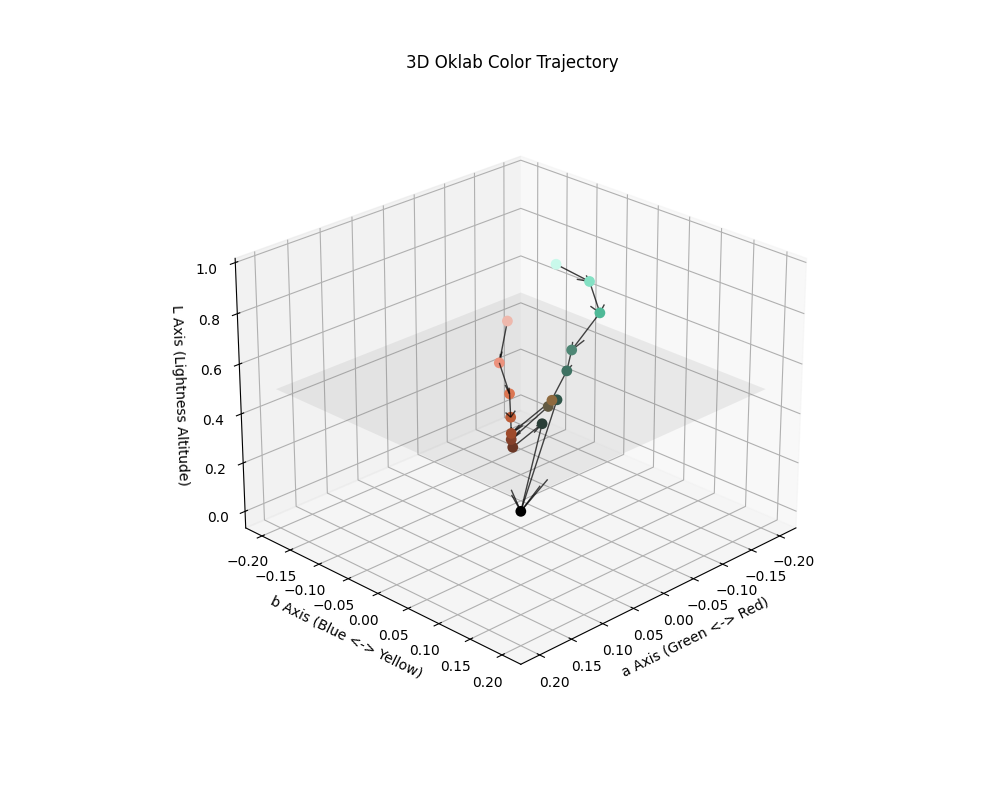

In [27]:
def graph_colors(oklab_points, ramp=None):
    rgb_colors = oklab_to_srgb(oklab_points) / 255
    rgb_colors = np.clip(rgb_colors, 0.0, 1.0)

    # Build the 3D Plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(projection='3d')

    # Map the coordinates: X=a, Y=b, Z=L (Lightness as altitude)
    # We pass our converted rgb_colors array directly to the 'c' argument
    x = oklab_points[:, 1]  # a
    y = oklab_points[:, 2]  # b
    z = oklab_points[:, 0]  # L

    sc = ax.scatter(
        x, y, z,
        c=rgb_colors,
        s=60,
        edgecolors='none',
        alpha=1.0
    )

    # Draw directed edges
    if ramp is not None:
        rows, cols = np.nonzero(ramp)

        print(len(rows))
        print(list(zip(rows[:10], cols[:10])))

        for i, j in zip(rows, cols):
            if i == j:
                continue

            start = np.array([x[i], y[i], z[i]])
            end   = np.array([x[j], y[j], z[j]])

            vec = end - start

            ax.quiver(
                start[0], start[1], start[2],
                vec[0], vec[1], vec[2],
                arrow_length_ratio=0.25,
                color='black',
                linewidth=1,
                alpha=0.75,
                normalize=False
            )

    # Formatting the structural layout
    ax.set_xlabel('a Axis (Green <-> Red)')
    ax.set_ylabel('b Axis (Blue <-> Yellow)')
    ax.set_zlabel('L Axis (Lightness Altitude)')
    ax.set_title('3D Oklab Color Trajectory', pad=20)

    # Subtle gray plane at L=0.5 to anchor the center "neutral" axis
    xx, yy = np.meshgrid(np.linspace(-0.2, 0.2, 2), np.linspace(-0.2, 0.2, 2))
    ax.plot_surface(xx, yy, np.full_like(xx, 0.5), color='gray', alpha=0.1, zorder=0)

    # Adjust viewing angle to easily see the hue curves and lightness height
    ax.view_init(elev=25, azim=45)
    plt.show()

%matplotlib widget

# oklab_points = oklab_arr.reshape(-1, 4)[:, :-1]
oklab_points = np.asarray(unique_colors)[:, :-1]
graph_colors(oklab_points, ramp=ramp_matrix)

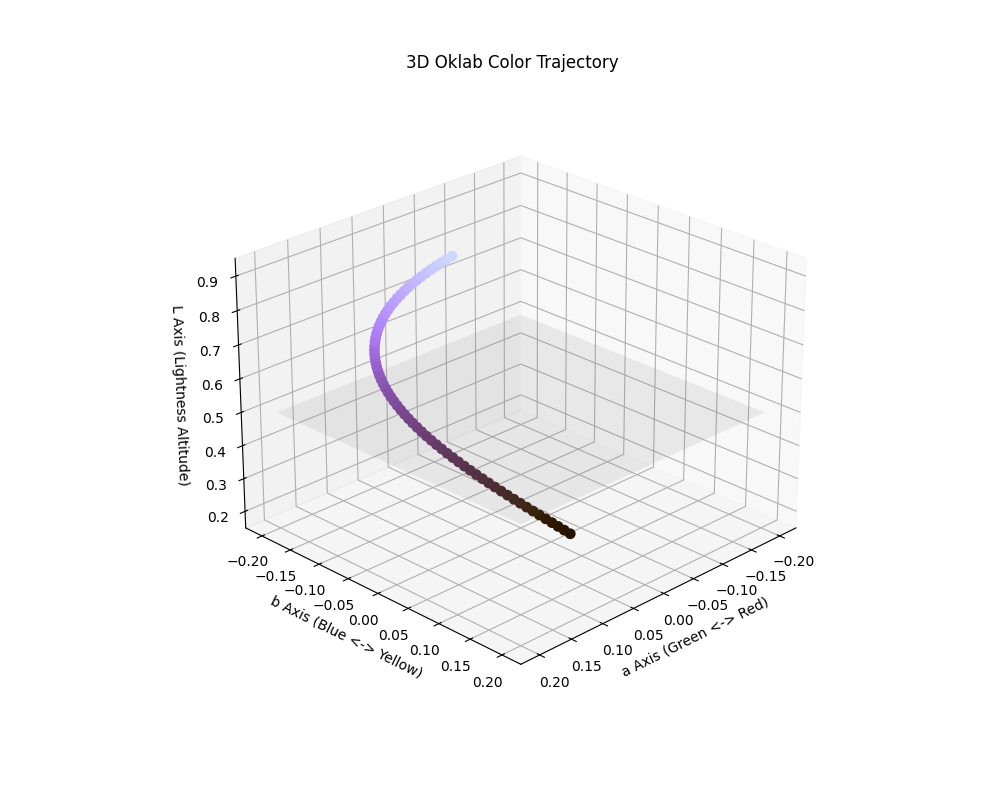

In [28]:
def test_purple_samples():
    num_points = 70
    L = np.linspace(0.2, 0.9, num_points)       # Monotonically increasing lightness
    a = np.sin(np.linspace(0, 3, num_points)) * 0.1  # Shifting red/green profile
    b = np.cos(np.linspace(1, 4, num_points)) * 0.15 # Shifting yellow/blue profile

    # Stack them into an (N, 3) array of Oklab coordinates
    return np.column_stack((L, a, b))

graph_colors(test_purple_samples())